In [1]:
from preprocessing import *
from preprocessing_bea import *
import numpy as np
import matplotlib.pyplot as plt
from helpers import *
from implementations import *
from model_functions import *

In [2]:
data_folder = 'C:/Users/ACER/OneDrive - epfl.ch/Desktop/ML/dataset/'


In [3]:
x_train,x_test, y_train,  feature_names = preprocess_data(data_folder, 0.3, True, 5, True, True, 0.95)

Dropped 180 features (56.1%)
Dropped feature names: ['CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE2', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'PREGNANT', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'EXRACT11', 'EXEROFT1', 'EXERHMM1', 'EXRACT21', 'EXEROFT2', 'EXERHMM2', 'LMTJOIN3', 'ARTHDIS2', 'ARTHSOCL', 'JOINPAIN', 'FLSHTMY2', 'IMFVPLAC', 'HIVTSTD3', 'WHRTST10', 'PDIABTST', 'PREDIAB1', 'INSULIN', 'BLDSUGAR', 'FEETCHK2', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM', 'DIABEYE', 'DIABEDU', 'CAREGIV1', 'CRGVREL1', 'CRGVLNG1', 'CRGVHRS1', 'CRGVPRB1', 'CRGVPERS', 'CRGVHOUS', 'CRGVMST2', 'CRGVEXPT', 'VIDFCLT2', 'VIREDIF3', 'VIPRFVS2', 'VINOCRE2', 'VIEYEXM2', 'VIINSUR2', 'VICTRCT4', 'VIGLUMA2', 'VIMACDG2', 'CIMEMLOS', 'CDHOUSE', 'CDASSIST', 'CDHELP', 'CDSOCIAL', 'CDDISCU

## Model Training and evaluation

In [4]:
# Converting y to binary 0/1
y_train_bin = (y_train == 1).astype(int)


In [5]:
# Splitting training data into training and validation sets
x_tr, y_tr, x_val, y_val = split_train_val(x_train, y_train_bin, val_size=0.1)

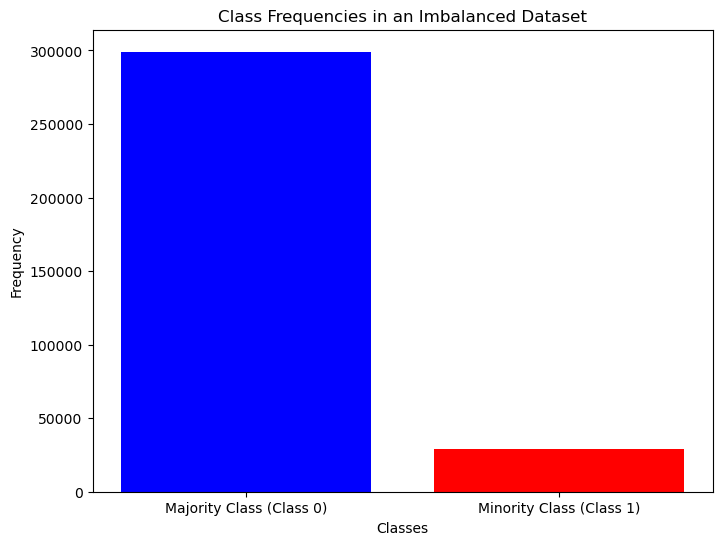

In [6]:

# Count the frequencies of each class
class_counts = [len(y_train_bin[y_train_bin == 0]), len(y_train_bin[y_train_bin == 1])]

# Plot the class frequencies using a bar chart
plt.figure(figsize=(8, 6))
plt.bar(['Majority Class (Class 0)', 'Minority Class (Class 1)'], class_counts, color=['blue', 'red'])
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Class Frequencies in an Imbalanced Dataset')
plt.show()

## Feature expansion

Things to fine tune: \
Polynomial expansion (degree) \
learning rate \
regularization \
oversampling \
threshold \
weighted logistic loss


## Logistic regression

### Changing gamma and max iter

First testing logistic regression without regularization

Iter 0/1000 - Loss: 0.68039
Iter 10/1000 - Loss: 0.57733
Iter 20/1000 - Loss: 0.50760
Iter 30/1000 - Loss: 0.45939
Iter 40/1000 - Loss: 0.42521
Iter 50/1000 - Loss: 0.40036
Iter 60/1000 - Loss: 0.38188
Iter 70/1000 - Loss: 0.36783
Iter 80/1000 - Loss: 0.35695
Iter 90/1000 - Loss: 0.34837
Iter 100/1000 - Loss: 0.34150
Iter 110/1000 - Loss: 0.33592
Iter 120/1000 - Loss: 0.33133
Iter 130/1000 - Loss: 0.32750
Iter 140/1000 - Loss: 0.32426
Iter 150/1000 - Loss: 0.32150
Iter 160/1000 - Loss: 0.31912
Iter 170/1000 - Loss: 0.31705
Iter 180/1000 - Loss: 0.31522
Iter 190/1000 - Loss: 0.31360
Iter 200/1000 - Loss: 0.31214
Iter 210/1000 - Loss: 0.31083
Iter 220/1000 - Loss: 0.30962
Iter 230/1000 - Loss: 0.30852
Iter 240/1000 - Loss: 0.30750
Iter 250/1000 - Loss: 0.30655
Iter 260/1000 - Loss: 0.30566
Iter 270/1000 - Loss: 0.30482
Iter 280/1000 - Loss: 0.30402
Iter 290/1000 - Loss: 0.30327
Iter 300/1000 - Loss: 0.30254
Iter 310/1000 - Loss: 0.30185
Iter 320/1000 - Loss: 0.30118
Iter 330/1000 - Loss:

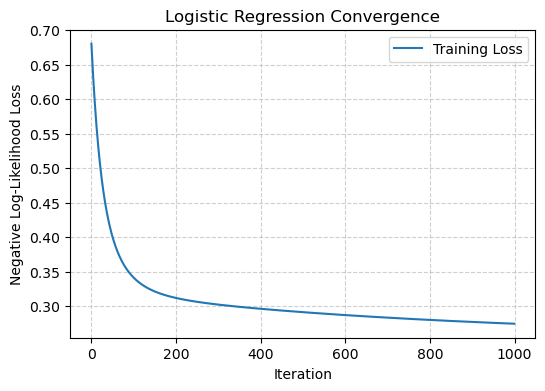

In [7]:
w, loss = logistic_regression(y_tr, x_tr, np.zeros(x_tr.shape[1]), 1000, 0.01 )

Iter 0/1000 - Loss: 0.57705
Iter 10/1000 - Loss: 0.33303
Iter 20/1000 - Loss: 0.31015
Iter 30/1000 - Loss: 0.30165
Iter 40/1000 - Loss: 0.29587
Iter 50/1000 - Loss: 0.29108
Iter 60/1000 - Loss: 0.28692
Iter 70/1000 - Loss: 0.28324
Iter 80/1000 - Loss: 0.27999
Iter 90/1000 - Loss: 0.27710
Iter 100/1000 - Loss: 0.27454
Iter 110/1000 - Loss: 0.27226
Iter 120/1000 - Loss: 0.27022
Iter 130/1000 - Loss: 0.26839
Iter 140/1000 - Loss: 0.26675
Iter 150/1000 - Loss: 0.26526
Iter 160/1000 - Loss: 0.26392
Iter 170/1000 - Loss: 0.26269
Iter 180/1000 - Loss: 0.26158
Iter 190/1000 - Loss: 0.26055
Iter 200/1000 - Loss: 0.25961
Iter 210/1000 - Loss: 0.25874
Iter 220/1000 - Loss: 0.25794
Iter 230/1000 - Loss: 0.25719
Iter 240/1000 - Loss: 0.25649
Iter 250/1000 - Loss: 0.25584
Iter 260/1000 - Loss: 0.25523
Iter 270/1000 - Loss: 0.25466
Iter 280/1000 - Loss: 0.25411
Iter 290/1000 - Loss: 0.25360
Iter 300/1000 - Loss: 0.25312
Iter 310/1000 - Loss: 0.25265
Iter 320/1000 - Loss: 0.25222
Iter 330/1000 - Loss:

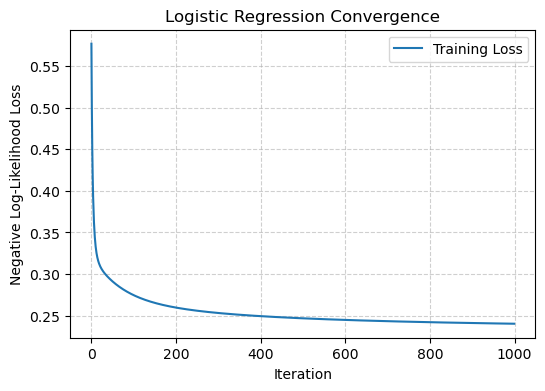

In [9]:
w_1, loss_1 = logistic_regression(y_tr, x_tr, np.zeros(x_tr.shape[1]), 1000, 0.1 )

Iter 0/10000 - Loss: 0.33887
Iter 10/10000 - Loss: 0.28898
Iter 20/10000 - Loss: 0.27329
Iter 30/10000 - Loss: 0.26449
Iter 40/10000 - Loss: 0.25911
Iter 50/10000 - Loss: 0.25549
Iter 60/10000 - Loss: 0.25286
Iter 70/10000 - Loss: 0.25081
Iter 80/10000 - Loss: 0.24916
Iter 90/10000 - Loss: 0.24778
Iter 100/10000 - Loss: 0.24660
Iter 110/10000 - Loss: 0.24558
Iter 120/10000 - Loss: 0.24469
Iter 130/10000 - Loss: 0.24390
Iter 140/10000 - Loss: 0.24319
Iter 150/10000 - Loss: 0.24256
Iter 160/10000 - Loss: 0.24199
Iter 170/10000 - Loss: 0.24147
Iter 180/10000 - Loss: 0.24100
Iter 190/10000 - Loss: 0.24057
Iter 200/10000 - Loss: 0.24017
Iter 210/10000 - Loss: 0.23981
Iter 220/10000 - Loss: 0.23948
Iter 230/10000 - Loss: 0.23917
Iter 240/10000 - Loss: 0.23888
Iter 250/10000 - Loss: 0.23861
Iter 260/10000 - Loss: 0.23836
Iter 270/10000 - Loss: 0.23812
Iter 280/10000 - Loss: 0.23791
Iter 290/10000 - Loss: 0.23770
Iter 300/10000 - Loss: 0.23751
Iter 310/10000 - Loss: 0.23732
Iter 320/10000 - Lo

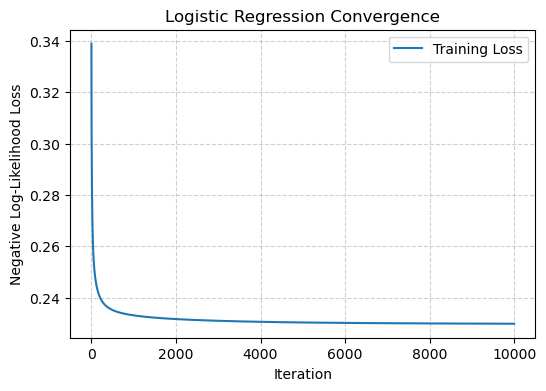

In [10]:
w_2, loss_2 = logistic_regression(y_tr, x_tr, np.zeros(x_tr.shape[1]), 10000, 0.5 )

In [12]:
w_r, loss_r = reg_logistic_regression(y_tr, x_tr,0.1, np.zeros(x_tr.shape[1]), 10000, 0.5 )

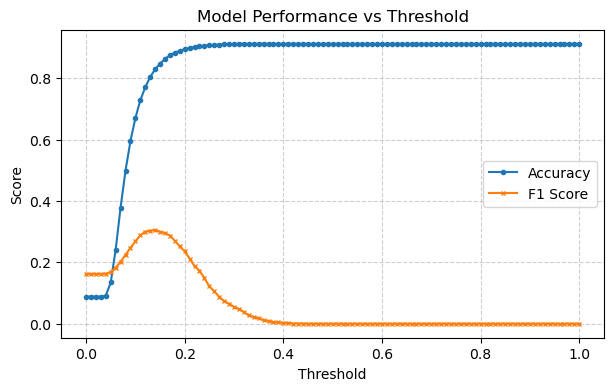

Best F1 threshold: 0.14 | F1 = 0.305, Accuracy = 0.829


(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 [0.08828817846585195,
  0.08828817846585195,
  0.08828817846585195,
  0.08828817846585195,
  0.09157955688294274,
  0.13430652485295463,
  0.24091061469539513,
  0.3784780422393563,
  0.49867430591533846,
  0.5949776003413282,
  0.669582177795386,
  0.7279431932465791,
  0.7701215981470758,
  0.803522993935330

In [19]:
plot_threshold_performance(x_val, y_val, w)

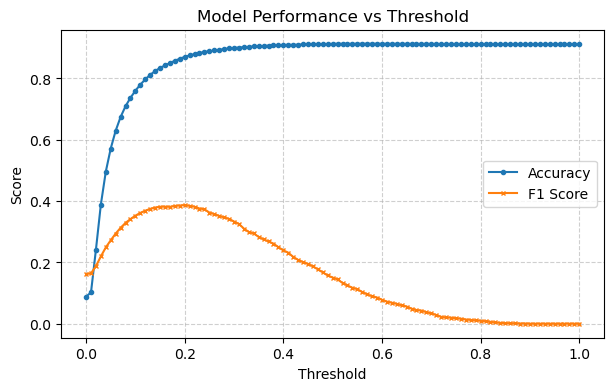

Best F1 threshold: 0.20 | F1 = 0.387, Accuracy = 0.870


(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 [0.08828817846585195,
  0.10203273092981441,
  0.2413982263127419,
  0.38880931338189134,
  0.49593149056776276,
  0.5713589126260933,
  0.6294151708164447,
  0.6741840124340962,
  0.7093225246091488,
  0.7367202023588212,
  0.7599122299088776,
  0.7798738304940115,
  0.7967573827446439,
  0.8119342943345625,


In [20]:
plot_threshold_performance(x_val,y_val, w_1)

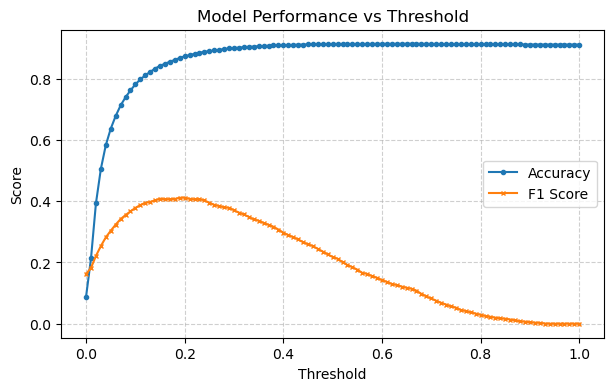

Best F1 threshold: 0.19 | F1 = 0.411, Accuracy = 0.868


(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 [0.08828817846585195,
  0.21336055831530187,
  0.3928321092250023,
  0.5056532471886143,
  0.5828787370859111,
  0.6368512479809831,
  0.6782982354554598,
  0.7127967573827446,
  0.7395849206107336,
  0.7618017249260963,
  0.7817633255112303,
  0.7977935574315058,
  0.8112333526346265,
  0.8224788955596867,
  

In [21]:
plot_threshold_performance(x_val, y_val, w_2)

Best is: gamma 10000, lr 0.5, threshold 0.19

### Now with regularization

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def grid_search_lambda_thresholds(y_tr, x_tr, x_val, y_val, lambda_values, max_iters=10000, gamma=0.5):
    """
    Perform grid search over regularization parameter lambda
    and plot Accuracy and F1 vs threshold for each lambda.

    Args:
        y_tr (np.array): training labels
        x_tr (np.array): training features
        x_val (np.array): validation features
        y_val (np.array): validation labels
        lambda_values (list or np.array): values of lambda to test
        max_iters (int): number of iterations for training
        gamma (float): learning rate
    """
    plt.figure(figsize=(10, 5))

    thresholds = np.arange(0.0, 1.0, 0.02)
    colors = plt.cm.viridis(np.linspace(0, 1, len(lambda_values)))

    for idx, lambda_ in enumerate(lambda_values):
        # Train model with current lambda
        w_r, loss_r = reg_logistic_regression(y_tr, x_tr, lambda_, np.zeros(x_tr.shape[1]), max_iters, gamma)
        
        f1_scores, accuracies = [], []
        for threshold in thresholds:
            y_pred, _ = logistic_regression_predict(x_val, w_r, 0.0, threshold)
            acc, f1,_ = evaluate_classification(y_val, y_pred)
            f1_scores.append(f1)
            accuracies.append(acc)

        # Plot F1 and Accuracy for this lambda
        plt.plot(thresholds, f1_scores, label=f'F1 (λ={lambda_})', color=colors[idx], linestyle='-')
        plt.plot(thresholds, accuracies, label=f'Acc (λ={lambda_})', color=colors[idx], linestyle='--')

    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('F1 and Accuracy vs Threshold for Different λ values')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\model_functions.py:42: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))
c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\model_functions.py:148: RuntimeWarning: overflow encountered in matmul
  (y ∈ {0,1}, with regularization term λ∥w∥2)
c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\model_functions.py:149: RuntimeWarning: overflow encountered in multiply
  
c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\model_functions.py:148: RuntimeWarning: invalid value encountered in matmul
  (y ∈ {0,1}, with regularization term λ∥w∥2)


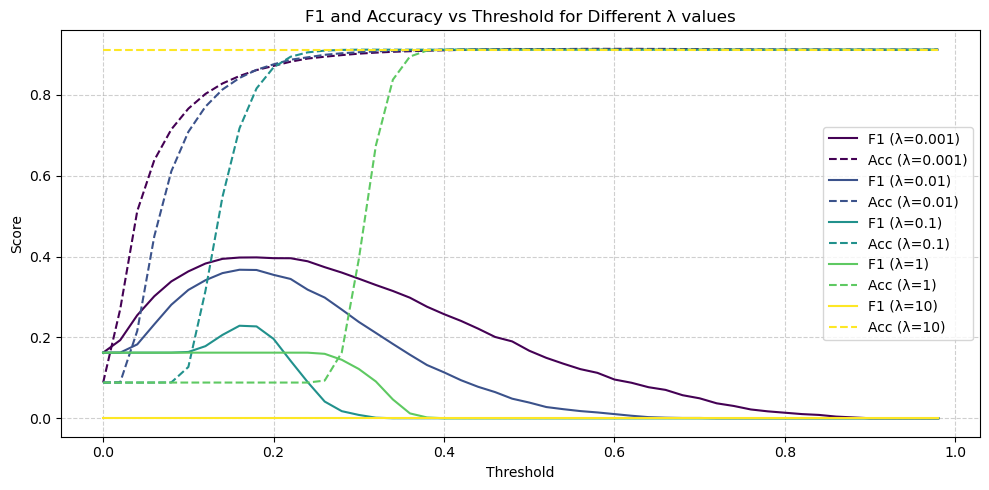

In [27]:
lambda_values = [0.001, 0.01, 0.1, 1, 10]
grid_search_lambda_thresholds(y_tr, x_tr, x_val, y_val, lambda_values, max_iters=10000, gamma=0.5)


In [ ]:
w_r_1, loss_r_1 = reg_logistic_regression(y_tr, x_tr, lambda_= 0.001, initial_w=np.zeros(x_tr.shape[1]), max_iters= 10000, gamma=0.5)

plot_threshold_performance(x_val, y_val, w_r_1)

In [32]:
def grid_search_lambda_thresholds_weighted(y_tr, x_tr, x_val, y_val, lambda_values, max_iters=10000, gamma=0.5):
    """
    Perform grid search over regularization parameter lambda
    and plot Accuracy and F1 vs threshold for each lambda.

    Args:
        y_tr (np.array): training labels
        x_tr (np.array): training features
        x_val (np.array): validation features
        y_val (np.array): validation labels
        lambda_values (list or np.array): values of lambda to test
        max_iters (int): number of iterations for training
        gamma (float): learning rate
    """
    plt.figure(figsize=(10, 5))

    thresholds = np.arange(0.0, 1.0, 0.02)
    colors = plt.cm.viridis(np.linspace(0, 1, len(lambda_values)))

    for idx, lambda_ in enumerate(lambda_values):
        # Train model with current lambda
        w_w, loss_w = train_logreg_weighted(x_tr, y_tr, gamma, max_iters, lambda_)
        
        f1_scores, accuracies = [], []
        for threshold in thresholds:
            y_pred, _ = logistic_regression_predict(x_val, w_w, 0.0, threshold)
            acc, f1 ,_= evaluate_classification(y_val, y_pred)
            f1_scores.append(f1)
            accuracies.append(acc)

        # Plot F1 and Accuracy for this lambda
        plt.plot(thresholds, f1_scores, label=f'F1 (λ={lambda_})', color=colors[idx], linestyle='-')
        plt.plot(thresholds, accuracies, label=f'Acc (λ={lambda_})', color=colors[idx], linestyle='--')

    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('F1 and Accuracy vs Threshold for Different λ values')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
w_w, b_w = train_logreg_weighted(x_tr,y_tr, lr=0.5, epochs=10000, lambda_=0.01)

c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\preprocessing_bea.py:658: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


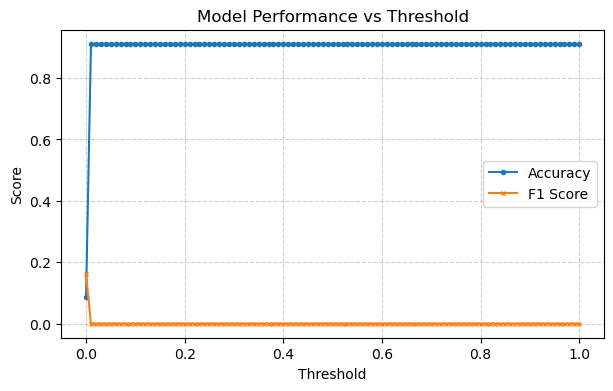

Best F1 threshold: 0.00 | F1 = 0.162, Accuracy = 0.088


(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 [0.08828817846585195,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0.9117118215341481,
  0

In [ ]:
plot_threshold_performance(x_val, y_val, w_w)

c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\model_functions.py:56: RuntimeWarning: overflow encountered in matmul
  z = x @ w + b
c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\model_functions.py:59: RuntimeWarning: overflow encountered in multiply
  dw = (x.T @ err) / N + lambda_ * w
c:\Users\ACER\OneDrive - epfl.ch\Desktop\ML\MilaLyon\model_functions.py:56: RuntimeWarning: invalid value encountered in matmul
  z = x @ w + b


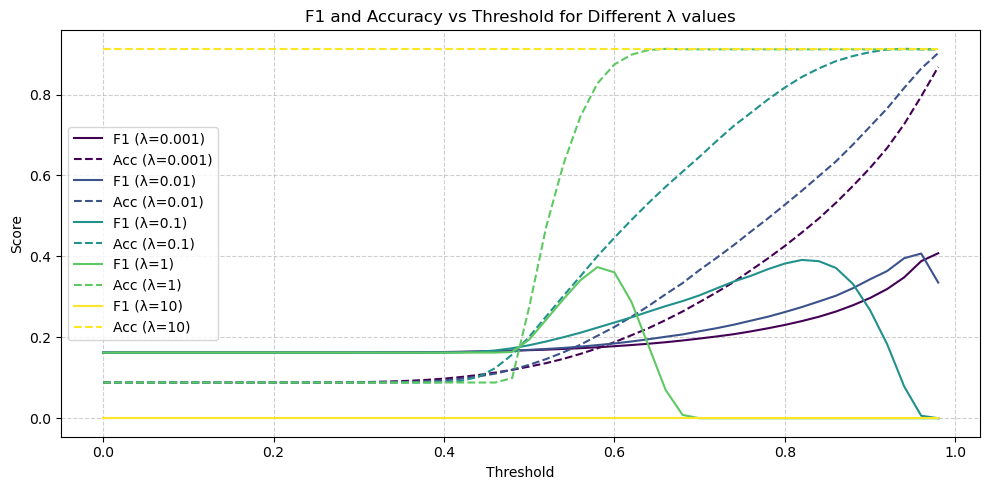

In [33]:
lambda_values = [0.001, 0.01, 0.1, 1, 10] ## Check what's b
grid_search_lambda_thresholds_weighted(y_tr, x_tr, x_val, y_val, lambda_values, max_iters=10000, gamma=0.5)

### Feature expansion

### Oversampling